# Delivery Time Prediction

In [1]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from geopy.distance import geodesic # Used to calculate the distance between 2 geographical locations

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')



In [2]:
## Load and Understand Data
df_train = pd.read_csv('/content/train.csv')
df_train.head(2)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33


In [3]:
df_train.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [4]:
df_train.shape

(45593, 20)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [9]:
# Checking statistical values for numerical fields with better visibility
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [10]:
# Checking the statistical values of other datatypes
df_train.describe(exclude=np.number).T

,count,unique,top,freq
ID,45593,45593,0x5fb2,1
Delivery_person_ID,45593,1320,PUNERES01DEL01,67
Delivery_person_Age,45593,23,35,2262
Delivery_person_Ratings,45593,29,4.8,7148
Order_Date,45593,44,15-03-2022,1192
Time_Orderd,45593,177,NaN,1731
Time_Order_picked,45593,193,21:30:00,496
Weatherconditions,45593,7,conditions Fog,7654
Road_traffic_density,45593,5,Low,15477
Type_of_order,45593,4,Snack,11533


In [11]:
# There are null values present in Time_Ordered Column
# Data formatting will be required for weather conditions & time_taken(min) columns.
# Both numerical & categorical features are present
# ID & Delivery person ID should not be used to build the model

# Explore each column
for column in df_train.columns:
  print(column)
  print(df_train[column].value_counts())
  print("---------------------------------------")



ID
ID
0x5fb2     1
0x4607     1
0xb379     1
0x5d6d     1
0x7a6a     1
          ..
0xdb64     1
0xc8b6     1
0x2784     1
0xd987     1
0xcdcd     1
Name: count, Length: 45593, dtype: int64
---------------------------------------
Delivery_person_ID
Delivery_person_ID
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64
---------------------------------------
Delivery_person_Age
Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
-----------------------

In [12]:
#Data cleaning

def update_column_name(df):
  # Renaming weather conditions column
  df.rename(columns={'Weatherconditions': 'Weather_conditions'}, inplace=True)

update_column_name(df_train)
print(df_train.columns)


Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')


In [13]:
# Extracting relevant values from column
def extract_column_value(df):
  # Extract time and convert it to integer
  df['Time_taken(min)'] = df['Time_taken(min)'].apply(lambda x: int(x.split(' ')[1].strip()))
  # Extract weather conditions
  df['Weather_conditions']= df['Weather_conditions'].apply(lambda x:x.split(' ')[1].strip())

  # Extract city code from delivery person ID
  df['City_code'] = df['Delivery_person_ID'].str.split("RES", expand=True)[0]

extract_column_value(df_train)
df_train[['Time_taken(min)', 'Weather_conditions', 'City_code']].head()



,Time_taken(min),Weather_conditions,City_code
0,24,Sunny,INDO
1,33,Stormy,BANG
2,26,Sandstorms,BANG
3,21,Sunny,COIMB
4,30,Cloudy,CHEN


In [14]:
# Drop columns that are not useful
def drop_columns(df):
  df.drop(['ID', 'Delivery_person_ID'], axis=1, inplace=True)

drop_columns(df_train)
df_train.head(2)

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code
0,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,INDO
1,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,BANG


In [15]:
## Checking for duplicate values
if (len(df_train[df_train.duplicated()]) > 0):
  print("Duplicate values present")
else:
  print("No duplicate values")

No duplicate values


In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  object 
 1   Delivery_person_Ratings      45593 non-null  object 
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Order_Date                   45593 non-null  object 
 7   Time_Orderd                  45593 non-null  object 
 8   Time_Order_picked            45593 non-null  object 
 9   Weather_conditions           45593 non-null  object 
 10  Road_traffic_density         45593 non-null  object 
 11  Vehicle_condition            45593 non-null  int64  
 12  Type_of_order                45593 non-null  object 
 13  Type_of_vehicle 

In [17]:
# Update datatypes
def update_datatypes(df):
  df['Delivery_person_Age'] = df['Delivery_person_Age'].astype('float64')
  df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype('float64')
  df['multiple_deliveries'] = df['multiple_deliveries'].astype('float64')
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

update_datatypes(df_train)


In [18]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Delivery_person_Age          43739 non-null  float64       
 1   Delivery_person_Ratings      43685 non-null  float64       
 2   Restaurant_latitude          45593 non-null  float64       
 3   Restaurant_longitude         45593 non-null  float64       
 4   Delivery_location_latitude   45593 non-null  float64       
 5   Delivery_location_longitude  45593 non-null  float64       
 6   Order_Date                   45593 non-null  datetime64[ns]
 7   Time_Orderd                  45593 non-null  object        
 8   Time_Order_picked            45593 non-null  object        
 9   Weather_conditions           45593 non-null  object        
 10  Road_traffic_density         45593 non-null  object        
 11  Vehicle_condition            45593 non-nu

In [19]:

## Convering string 'NaN' to np.nan
def convert_nan(df):
  df.replace('NaN', float(np.nan), regex=True, inplace=True)

convert_nan(df_train)


In [21]:
df_train.isnull().sum().sort_values(ascending=False)


,0
Delivery_person_Ratings,1908
Delivery_person_Age,1854
Time_Orderd,1731
City,1200
multiple_deliveries,993
Weather_conditions,616
Road_traffic_density,601
Festival,228
Restaurant_latitude,0
Order_Date,0


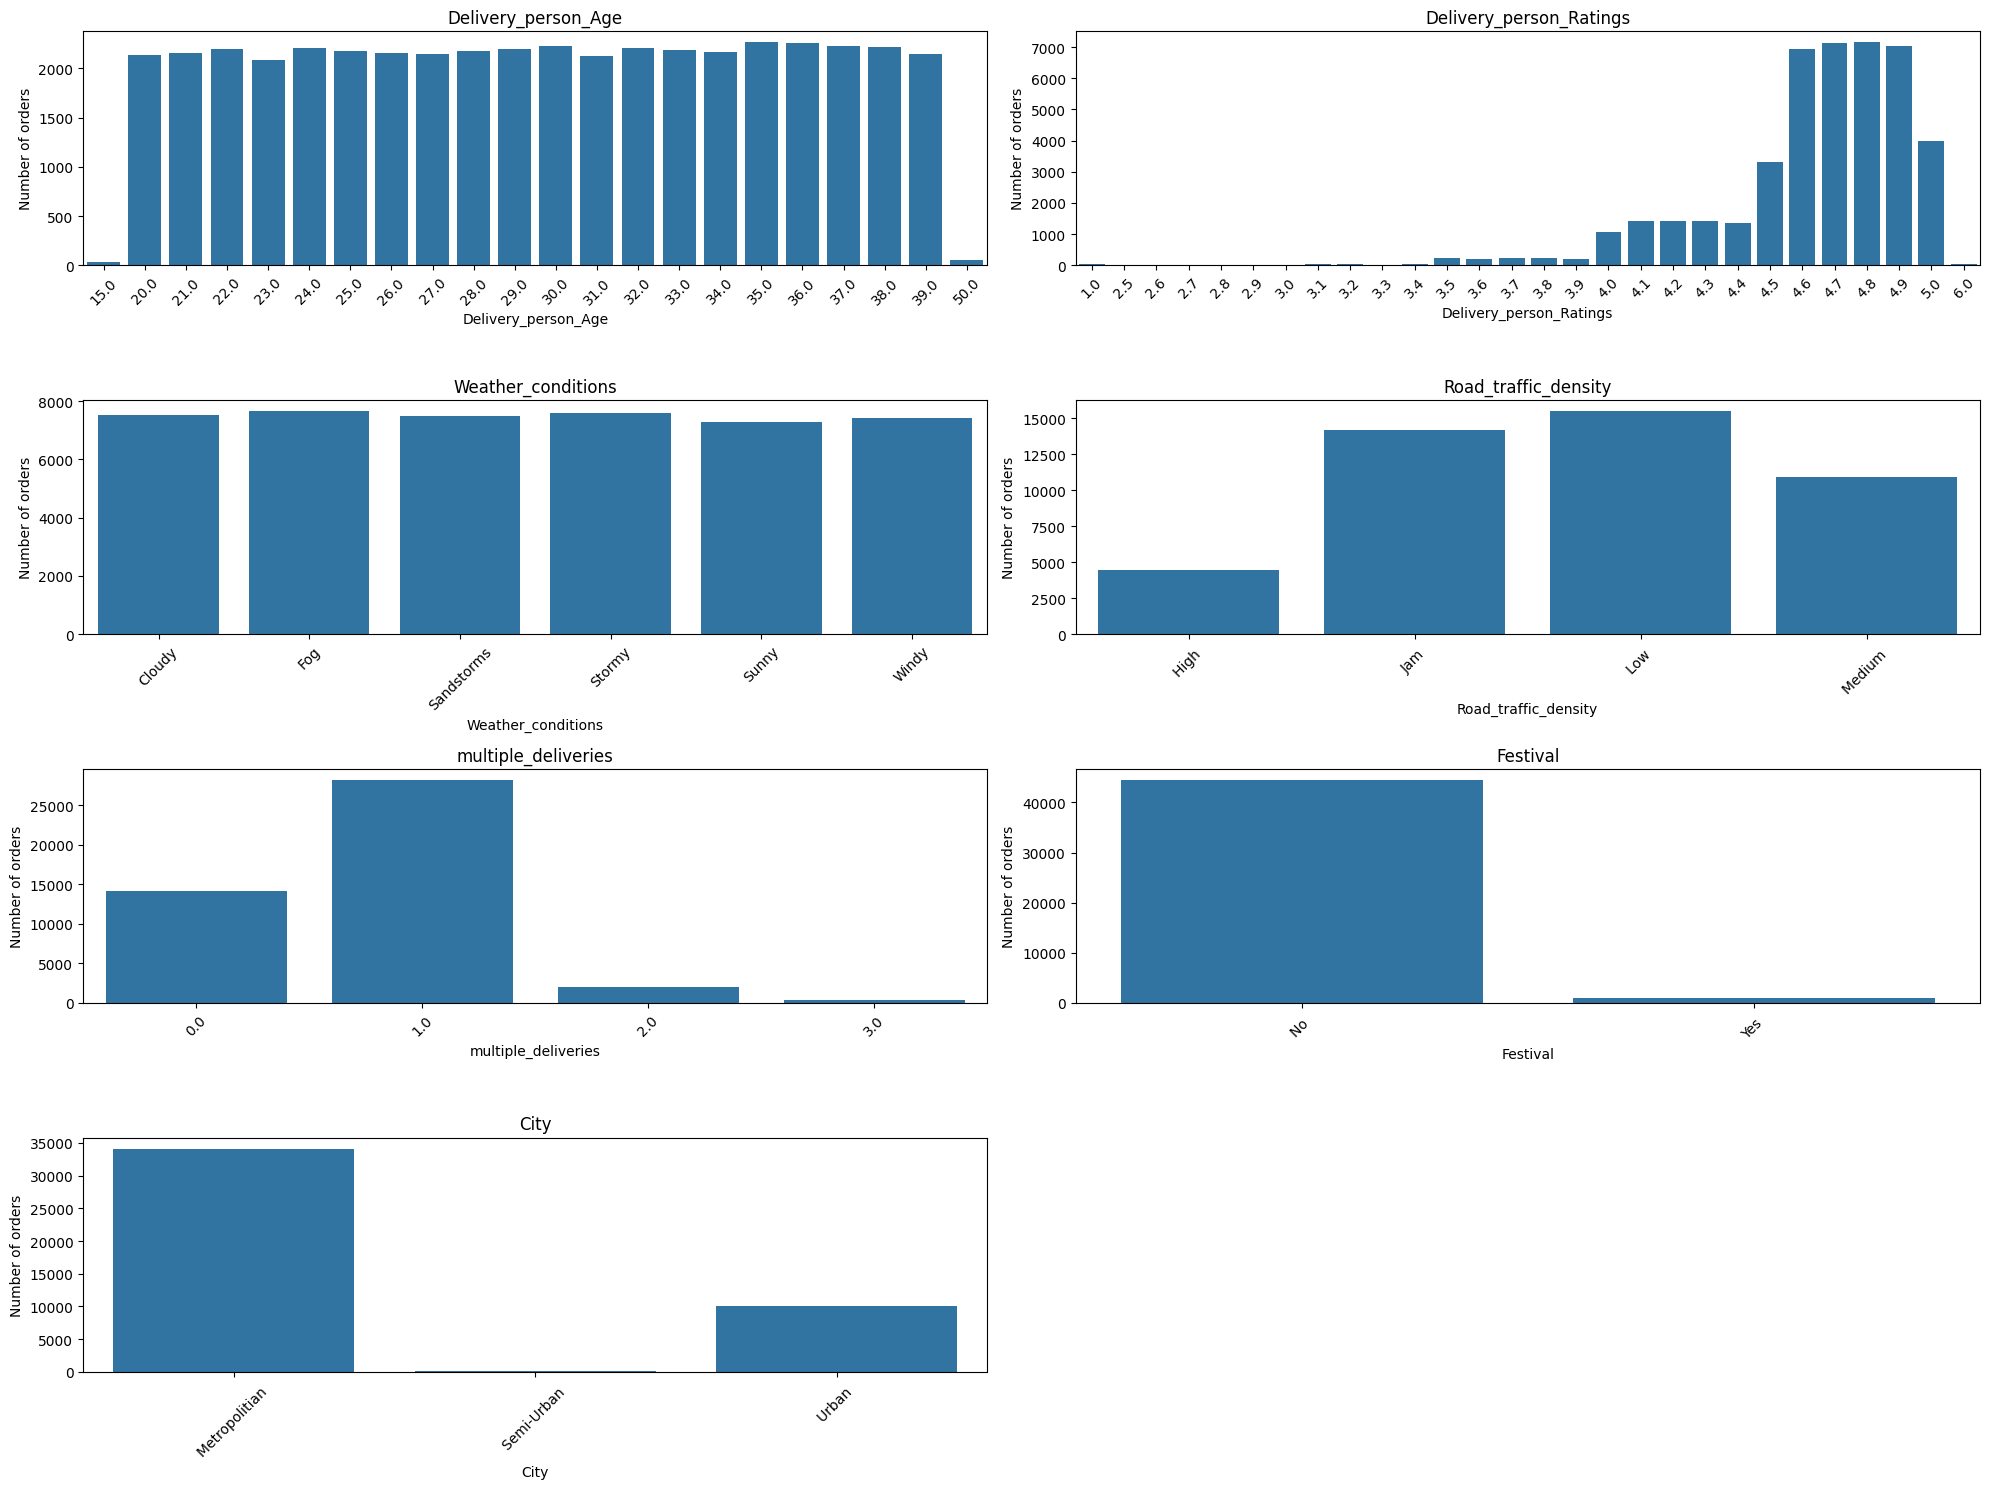

In [22]:

cols=['Delivery_person_Age', 'Delivery_person_Ratings', 'Weather_conditions', 'Road_traffic_density', 'multiple_deliveries', 'Festival', 'City']
num_plots = len(cols)
num_rows = (num_plots //2) + (num_plots % 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(20, 15))

for i, column_name in enumerate(cols):
  row = i // 2
  col = i % 2

  ax = axes[row, col]
  sns.countplot(data=df_train, x=column_name, order=df_train[column_name].value_counts().sort_index().index, ax=ax)

  ax.set_xlabel(column_name)
  ax.set_ylabel("Number of orders")
  ax.set_title(column_name)
  ax.tick_params(axis='x', rotation=45)

if num_plots % 2 != 0:
  fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()




In [23]:
# Handling null values
def handle_null_values(df):
  df['Delivery_person_Age'].fillna(np.random.choice(df['Delivery_person_Age']), inplace=True) # Randomly filling the empty age since it will be realistic
  df['Weather_conditions'].fillna(np.random.choice(df['Weather_conditions']), inplace=True) # Radmonly filling again for realistic distribution
  df['City'].fillna(df['City'].mode()[0], inplace=True)
  df['Festival'].fillna(df['Festival'].mode()[0], inplace=True)
  df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0], inplace=True)
  df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0], inplace=True)
  df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)

handle_null_values(df_train)
df_train.isnull().sum()


,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731
Time_Order_picked,0
Weather_conditions,0


In [24]:
## Feature Engineering
def extract_data_features(data):
  data["day"] = data.Order_Date.dt.day
  data['month'] = data.Order_Date.dt.month
  data['quarter'] = data.Order_Date.dt.quarter
  data['year'] = data.Order_Date.dt.year
  data['day_of_week'] = data.Order_Date.dt.day_of_week.astype(int)
  data['is_month_start'] = data.Order_Date.dt.is_month_start.astype(int)
  data['is_month_end'] = data.Order_Date.dt.is_month_end.astype(int)
  data['is_quarter_start'] = data.Order_Date.dt.is_quarter_start.astype(int)
  data['is_quarter_end'] = data.Order_Date.dt.is_quarter_end.astype(int)
  data['is_year_start'] = data.Order_Date.dt.is_year_start.astype(int)
  data['is_year_end'] = data.Order_Date.dt.is_year_end.astype(int)
  data['is_weekend'] = np.where(data['day_of_week'].isin([5, 6]), 1, 0)

extract_data_features(df_train)
df_train.head(2)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0


In [26]:
df_train.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'City_code', 'day', 'month', 'quarter', 'year', 'day_of_week',
       'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end',
       'is_year_start', 'is_year_end', 'is_weekend'],
      dtype='object')

In [27]:
# Filling the null time_ordered column

import pandas as pd
import numpy as np

def calculate_time_diff(df):
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])

  # Handle null values in Time_ordered and Time_order_picked before conversion
  df['Time_Orderd'] = df['Time_Orderd'].fillna('00:00:00')
  df['Time_Order_picked'] = df['Time_Order_picked'].fillna('00:00:00')

  # Converting time to timedelta
  df['Time_Orderd'] = pd.to_timedelta(df['Time_Orderd'])
  df['Time_Order_picked'] = pd.to_timedelta(df['Time_Order_picked'])

  # Calculate base ordered and picked times
  df['Time_Ordered_formatted'] = df['Order_Date'] + df['Time_Orderd']
  df['Time_Order_picked_base'] = df['Order_Date'] + df['Time_Order_picked']

  # Adjust for cases where picked time is on the next day using a mask
  mask = df['Time_Order_picked'] < df['Time_Orderd']
  df['Time_Order_picked_formatted'] = df['Time_Order_picked_base'].copy()
  df.loc[mask, 'Time_Order_picked_formatted'] += pd.Timedelta(days=1)

  # Calculate preparation time in minutes
  df['order_prepare_time'] = (df['Time_Order_picked_formatted'] - df['Time_Ordered_formatted']).dt.total_seconds() /60

  # Handle null values in order_prepare_time by filling with median
  df['order_prepare_time'].fillna(df['order_prepare_time'].median(), inplace=True)

  # Drop unwanted columns
  df.drop(['Time_Orderd', 'Time_Order_picked', 'Time_Ordered_formatted', 'Time_Order_picked_base', 'Time_Order_picked_formatted', 'Order_Date'], axis=1, inplace=True)


calculate_time_diff(df_train)
df_train.head(2)




,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1,15.0
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0,5.0


In [30]:
## Calculate the distance between the restuarant location & delivery location

def calculate_distance(df):
  df['distance']=np.zeros(len(df))
  restaurant_coordinates=df[['Restaurant_latitude','Restaurant_longitude']].to_numpy()
  delivery_location_coordinates=df[['Delivery_location_latitude', 'Delivery_location_longitude']].to_numpy()
  df['distance'] = np.array([geodesic(restaurant, delivery) for restaurant, delivery in zip(restaurant_coordinates, delivery_location_coordinates)])
  df['distance'] = df['distance'].astype(str).str.extract('(\d+)').astype("int64")

calculate_distance(df_train)
df_train.head(2)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,INDO,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,3
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,BANG,25,3,1,2022,4,0,0,0,0,0,0,0,5.0,20


In [31]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  float64
 1   Delivery_person_Ratings      45593 non-null  float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weather_conditions           45593 non-null  object 
 7   Road_traffic_density         45593 non-null  object 
 8   Vehicle_condition            45593 non-null  int64  
 9   Type_of_order                45593 non-null  object 
 10  Type_of_vehicle              45593 non-null  object 
 11  multiple_deliveries          45593 non-null  float64
 12  Festival                     45593 non-null  object 
 13  City            

In [32]:
## Data Preprocessing
# Label Encoding

def label_encoding(df):
  categorical_columns = df.select_dtypes(include='object').columns
  label_encoder = LabelEncoder()
  df[categorical_columns] = df[categorical_columns].apply(lambda col: label_encoder.fit_transform(col))

label_encoding(df_train)
df_train.head(2)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),City_code,day,month,quarter,year,day_of_week,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,is_weekend,order_prepare_time,distance
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,4,0,2,3,2,0.0,0,2,24,10,19,3,1,2022,5,0,0,0,0,0,0,1,15.0,3
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,3,1,2,3,3,1.0,0,0,33,3,25,3,1,2022,4,0,0,0,0,0,0,0,5.0,20


In [33]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          45593 non-null  float64
 1   Delivery_person_Ratings      45593 non-null  float64
 2   Restaurant_latitude          45593 non-null  float64
 3   Restaurant_longitude         45593 non-null  float64
 4   Delivery_location_latitude   45593 non-null  float64
 5   Delivery_location_longitude  45593 non-null  float64
 6   Weather_conditions           45593 non-null  int64  
 7   Road_traffic_density         45593 non-null  int64  
 8   Vehicle_condition            45593 non-null  int64  
 9   Type_of_order                45593 non-null  int64  
 10  Type_of_vehicle              45593 non-null  int64  
 11  multiple_deliveries          45593 non-null  float64
 12  Festival                     45593 non-null  int64  
 13  City            

In [35]:
from sklearn.model_selection import train_test_split

# Train test split
X = df_train.drop('Time_taken(min)', axis=1)
y = df_train['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)




(36474, 29) (36474,)
(9119, 29) (9119,)


In [36]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [38]:
## Model Building

# Using cross validation to determine the optimal regression model
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    xgb.XGBRegressor()
]

param_grid = [
    {},
    {'max_depth': [3, 5, 7]},
    {'n_estimators': [100, 200, 300]},
    {'n_estimators': [20, 25, 30], 'max_depth': [5, 7, 9]}
]

for i, model in enumerate(models):
  grid_search = GridSearchCV(model, param_grid[i], cv=5, scoring='r2')
  grid_search.fit(X_train, y_train)

  print(f"{model.__class__.__name__}:")
  print("Best parameters: ", grid_search.best_params_)
  print("Best R2 score: ", grid_search.best_score_)
  print()

LinearRegression:
Best parameters:  {}
Best R2 score:  0.425318408359194

DecisionTreeRegressor:
Best parameters:  {'max_depth': 7}
Best R2 score:  0.7321064403122166

RandomForestRegressor:
Best parameters:  {'n_estimators': 300}
Best R2 score:  0.8163224645355239

XGBRegressor:
Best parameters:  {'max_depth': 7, 'n_estimators': 20}
Best R2 score:  0.8224872827529908



In [39]:
# Model Building
model = xgb.XGBRegressor(n_estimators=20, max_depth=7)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=20, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [40]:
# Evaluating the model
y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE): ", round(mae, 2))
print("Mean Squared Error (MSE): ", round(mse, 2))
print("Root Mean Squared Error (RMSE): ", round(rmse, 2))
print("R-squared (R2) score: ", round(r2, 2))


Mean Absolute Error (MAE):  3.16
Mean Squared Error (MSE):  15.68
Root Mean Squared Error (RMSE):  3.96
R-squared (R2) score:  0.82


Best parameters:  {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV R2:  0.8234307408332825
Ensemble Test R2: 0.8225321082685053
Ensemble Test RMSE:  3.9446234390884056
Top 12 Features
                    Feature  Importance
11      multiple_deliveries    0.210692
7      Road_traffic_density    0.114714
1   Delivery_person_Ratings    0.102225
8         Vehicle_condition    0.091248
30      distance_deliveries    0.091247
6        Weather_conditions    0.079234
28                 distance    0.055978
12                 Festival    0.054900
29         distance_traffic    0.046948
0       Delivery_person_Age    0.038758
31             prep_traffic    0.024943
13                     City    0.012442


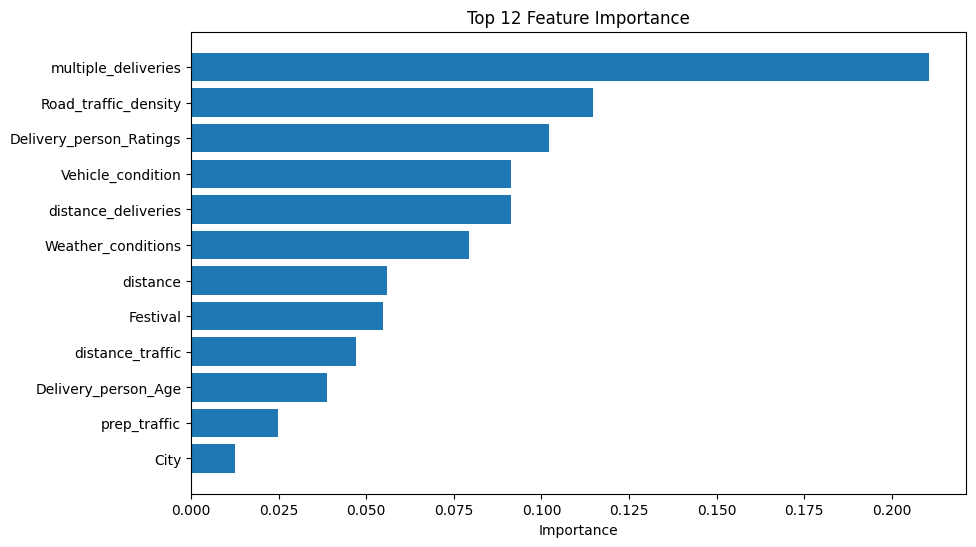

Test R2 with top 12:  0.822778046131134
Test RMSE with top 12:  3.9418892860412598


In [42]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt

# Adding new features
df_train['distance_traffic'] = df_train['distance'] * df_train['Road_traffic_density']
df_train['distance_deliveries'] = df_train['distance'] * df_train['multiple_deliveries']
df_train['prep_traffic'] = df_train['order_prepare_time'] * df_train['Road_traffic_density']
df_train['age_ratings'] = df_train['Delivery_person_Age'] * df_train['Delivery_person_Ratings']
df_train['prep_distance'] = df_train['order_prepare_time'] * df_train['distance']

# Handling outliers
for col in ['distance', 'order_prepare_time', 'Delivery_person_Age', 'multiple_deliveries']:
  upper_limit = df_train[col].quantile(0.99)
  df_train[col] = np.where(df_train[col] > upper_limit, upper_limit, df_train[col])

# Spliting and scaling
X = df_train.drop('Time_taken(min)', axis=1)
y = df_train['Time_taken(min)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    xgb.XGBRegressor(),
    param_grid_xgb,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("Best parameters: ", random_search.best_params_)
print("Best CV R2: ", random_search.best_score_)

# Ensemble
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
ensemble_model = VotingRegressor([('xgb', best_model), ('rf', rf_model)])
ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_test)
print("Ensemble Test R2:", r2_score(y_test, y_pred_ensemble))
print("Ensemble Test RMSE: ", root_mean_squared_error(y_test, y_pred_ensemble))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance':best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Top 12 Features")
print(importance_df.head(12))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:12], importance_df['Importance'][:12])
plt.xlabel("Importance")
plt.title("Top 12 Feature Importance")
plt.gca().invert_yaxis()
plt.show()


# Retraining the modle with top 12 features
top_12_features = importance_df['Feature'][:12].tolist()
X_train_top12 = X_train[:, [X.columns.get_loc(col) for col in top_12_features]]
X_test_top12 = X_test[:, [X.columns.get_loc(col) for col in top_12_features]]
best_model.fit(X_train_top12, y_train)
y_pred_top12 = best_model.predict(X_test_top12)
print("Test R2 with top 12: ", r2_score(y_test, y_pred_top12))
print("Test RMSE with top 12: ", root_mean_squared_error(y_test, y_pred_top12))



In [43]:
# Save the model using joblib
import joblib
joblib.dump(best_model, 'best_model.pkl')


['best_model.pkl']

In [44]:
import numpy as np
import pandas as pd
from geopy.distance import geodesic
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# Load test data
df_test = pd.read_csv('/content/test.csv')


def update_column_name(df):
  df.rename(columns={'Weatherconditions': 'Weather_conditions'}, inplace=True)

update_column_name(df_test)


def extract_column_value(df):
  df['Weather_conditions'] = df['Weather_conditions'].apply(lambda x: x.split(' ')[1].strip() if pd.notnull(x) else x)
  df['City_code'] = df['Delivery_person_ID'].str.split("RES", expand=True)[0]

extract_column_value(df_test)

def drop_columns(df):
  df.drop(['ID', 'Delivery_person_ID'], axis=1, inplace=True)

drop_columns(df_test)


def update_datatype(df):
  df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce').astype('float64')
  df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce').astype('float64')
  df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce').astype('float64')
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], format="%d-%m-%Y")

update_datatype(df_test)

def convert_nan(df):
  df.replace('NaN', float(np.nan), regex=True, inplace=True)

convert_nan(df_test)

def handle_null_values(df):
  df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(np.random.choice(df['Delivery_person_Age'].dropna()))
  df['Weather_conditions'] = df['Weather_conditions'].fillna(np.random.choice(df['Weather_conditions'].dropna()))
  df['City'] = df['City'].fillna(df['City'].mode()[0])
  df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])
  df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0])
  df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])
  df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

handle_null_values(df_test)

def extract_date_features(data):
    data["day"] = data.Order_Date.dt.day
    data["month"] = data.Order_Date.dt.month
    data["quarter"] = data.Order_Date.dt.quarter
    data["year"] = data.Order_Date.dt.year
    data['day_of_week'] = data.Order_Date.dt.day_of_week.astype(int)
    data["is_month_start"] = data.Order_Date.dt.is_month_start.astype(int)
    data["is_month_end"] = data.Order_Date.dt.is_month_end.astype(int)
    data["is_quarter_start"] = data.Order_Date.dt.is_quarter_start.astype(int)
    data["is_quarter_end"] = data.Order_Date.dt.is_quarter_end.astype(int)
    data["is_year_start"] = data.Order_Date.dt.is_year_start.astype(int)
    data["is_year_end"] = data.Order_Date.dt.is_year_end.astype(int)
    data['is_weekend'] = np.where(data['day_of_week'].isin([5, 6]), 1, 0)

extract_date_features(df_test)

# Step 8: Calculate Time Difference (Updated to avoid inplace warnings)
def calculate_time_diff(df):
    df['Order_Date'] = pd.to_datetime(df['Order_Date'])
    df['Time_Orderd'] = pd.to_timedelta(df['Time_Orderd'].fillna('00:00:00'))
    df['Time_Order_picked'] = pd.to_timedelta(df['Time_Order_picked'].fillna('00:00:00'))
    df['Time_Ordered_formatted'] = df['Order_Date'] + df['Time_Orderd']
    df['Time_Order_picked_base'] = df['Order_Date'] + df['Time_Order_picked']
    mask = df['Time_Order_picked'] < df['Time_Orderd']
    df['Time_Order_picked_formatted'] = df['Time_Order_picked_base'].copy()
    df.loc[mask, 'Time_Order_picked_formatted'] += pd.Timedelta(days=1)
    df['order_prepare_time'] = (df['Time_Order_picked_formatted'] - df['Time_Ordered_formatted']).dt.total_seconds() / 60
    df['order_prepare_time'] = df['order_prepare_time'].fillna(df['order_prepare_time'].median())
    df.drop(['Time_Orderd', 'Time_Order_picked', 'Time_Ordered_formatted',
             'Time_Order_picked_base', 'Time_Order_picked_formatted', 'Order_Date'],
            axis=1, inplace=True)

calculate_time_diff(df_test)

# Step 9: Calculate Distance
def calculate_distance(df):
    df['distance'] = np.zeros(len(df))
    restaurant_coordinates = df[['Restaurant_latitude', 'Restaurant_longitude']].to_numpy()
    delivery_location_coordinates = df[['Delivery_location_latitude', 'Delivery_location_longitude']].to_numpy()
    df['distance'] = np.array([geodesic(restaurant, delivery).km for restaurant, delivery in zip(restaurant_coordinates, delivery_location_coordinates)])

calculate_distance(df_test)


# Step 10: Label Encoding
def label_encoding(df):
    categorical_columns = df.select_dtypes(include='object').columns
    label_encoder = LabelEncoder()
    for col in categorical_columns:
        df[col] = label_encoder.fit_transform(df[col])

label_encoding(df_test)

# Step 11: Add New Features
df_test['distance_traffic'] = df_test['distance'] * df_test['Road_traffic_density']
df_test['distance_deliveries'] = df_test['distance'] * df_test['multiple_deliveries']
df_test['prep_traffic'] = df_test['order_prepare_time'] * df_test['Road_traffic_density']
df_test['age_ratings'] = df_test['Delivery_person_Age'] * df_test['Delivery_person_Ratings']
df_test['prep_distance'] = df_test['order_prepare_time'] * df_test['distance']

# Step 12: Handle Outliers
for col in ['distance', 'order_prepare_time', 'Delivery_person_Age', 'multiple_deliveries']:
    upper_limit = df_test[col].quantile(0.99)
    df_test[col] = np.where(df_test[col] > upper_limit, upper_limit, df_test[col])

# Step 13: Select Top 12 Features
top_12_features = [
    'multiple_deliveries', 'Road_traffic_density', 'Vehicle_condition', 'Delivery_person_Ratings',
    'distance_deliveries', 'Weather_conditions', 'Festival', 'distance_traffic', 'distance',
    'Delivery_person_Age', 'prep_traffic', 'City'
]

X_test_final = df_test[top_12_features]

# Step 14: Scale the Top 12 Features
# Since best_model.pkl was trained on scaled data, we need to scale these features
# Ideally, we’d use the scaler from training subsetted to these 12 features, but we’ll fit a new one for now
scaler_12 = StandardScaler()
X_test_final_scaled = scaler_12.fit_transform(X_test_final)

# Step 15: Load Model and Predict
best_model = joblib.load('best_model.pkl')
y_pred = best_model.predict(X_test_final_scaled)

# Step 16: Add Predictions to Original DataFrame (with ID)
df_test_with_id = pd.read_csv(r"/content/test.csv")
predictions_df = pd.DataFrame({
    'ID': df_test_with_id['ID'],
    'Predicted_Time_taken(min)': y_pred
})

# Print and Save Predictions
print(predictions_df.head())
predictions_df.to_csv('predictions.csv', index=False)
print("Predictions saved to 'predictions.csv'")



        ID  Predicted_Time_taken(min)
0  0x2318                   27.378275
1  0x3474                   37.322220
2  0x9420                   33.065548
3  0x72ee                   16.401505
4  0xa759                   27.308203
Predictions saved to 'predictions.csv'
